In [21]:
detach("package:SCOUT", unload = TRUE)

In [18]:
setwd('/dartfs/rc/lab/M/McKennaLab/projects/hannah/OU/revisions_analysis')

In [19]:
library(SCOUT)
library(progressr)
library(future.apply)
library(corpcor)
library(paleotree)
library(nloptr)
library(dplyr)
library(stringr)

suppressPackageStartupMessages({
  library(castor); library(ape); library(expm); library(Matrix); library(paleotree)
  library(ggplot2); library(reshape2)
})

source('../../cellfatebias/scripts/utilities.R')

In [20]:
#library(roxygen2)
#library(devtools)

In [21]:
# Not used 
#tree <- ape::read.tree('./simulation_revisions/260323_dropout/character_mats/260323_dropout_n256_TedSim_character_matrix_casNJ_tree.nwk')

In [36]:
set.seed(1)
ncells <- 256
P <- matrix(c(0.90, 0.08, 0.02,
              0.10, 0.80, 0.10,
              0.02, 0.08, 0.90),
            3, 3,
            byrow = T)
Q <- expm::logm(P)

simtree.obj <- generate_tree_hbd_reverse(ncells, rho = 1, lambda = 1, mu = 0)
states  <- castor::simulate_mk_model(simtree.obj$trees[[1]], Q = Q, include_nodes = FALSE)
simtree <- simtree.obj$trees[[1]]
simtree$tip.label <- paste0('t', simtree$tip.label)
simtree$states    <- as.factor(paste0('state', states$tip_states))
simtree <- infer_anc(simtree)
table(simtree$states)


state1 state2 state3 
   106     61     89 

In [37]:
max(branching.times(simtree)) * 5

[1] 23.69404

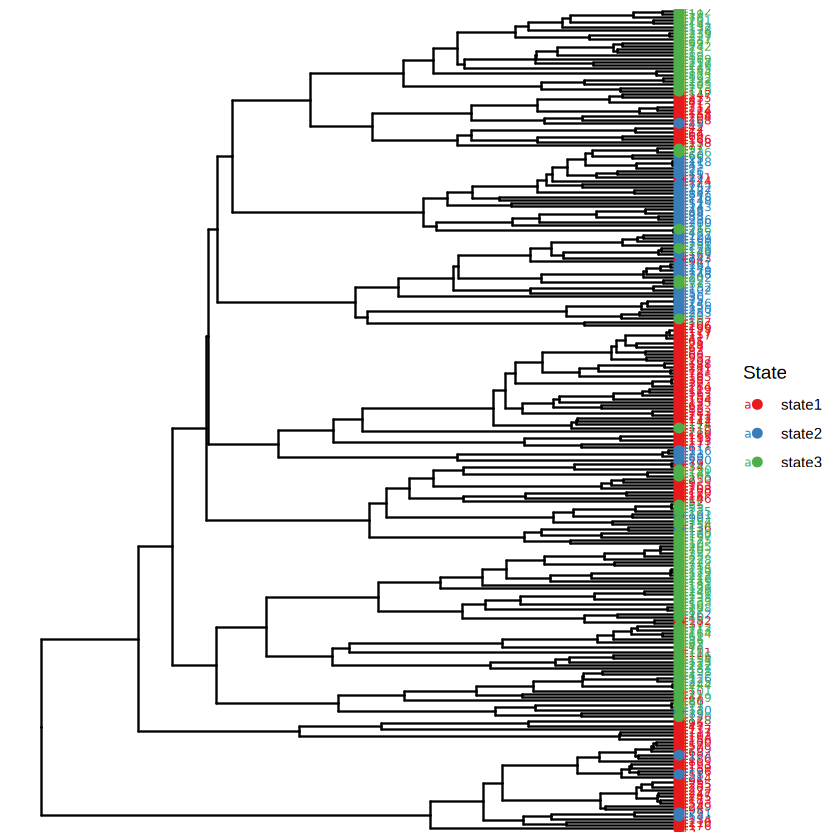

In [38]:
plot_tree_states(simtree)

In [39]:
# t0 must keep simulated traits positive: theta cannot be fitted below 1e-10
# (R/SCOUT_EM.R:213). BM tip sd is sigma*sqrt(height), so allow ~3 sd of headroom.
prefix  <- '260805_simtree_256cells_hbd_rev_fixed'
datadir <- './revision_v2/1_tree_robustness/data/'
alpha_i <- 3

simtest <- simulate_test_data(60, ncells, simtree,
                   outdir = datadir,
                   out_prefix = prefix,
                   a = alpha_i, s = 1, t0 = 8, theta_step = 2, sim_lin = FALSE)


2026-08-06 15:21:18.526418 | Simulating OU genes for 1 parameter combinations.

2026-08-06 15:21:23.489831 | Data generation complete



In [40]:
simtree$node.label <- NULL
treefile <- file.path(datadir, paste0(prefix, '.nwk'))
ape::write.tree(simtree, treefile)

# derive both data paths from the same prefix so tree and data cannot drift apart
countsfile <- file.path(datadir, sprintf('%s_alpha_%s_sigma_1_OUEVF_counts.csv', prefix, alpha_i))
evffile    <- file.path(datadir, sprintf('%s_alpha_%s_sigma_1_OUEVF_evf_counts.csv', prefix, alpha_i))
stopifnot(file.exists(treefile), file.exists(countsfile), file.exists(evffile))


In [41]:
list.files(datadir, pattern = prefix)


[1] "260805_simtree_256cells_hbd_rev_fixed_alpha_3_sigma_1_OUEVF_counts.csv"    
[2] "260805_simtree_256cells_hbd_rev_fixed_alpha_3_sigma_1_OUEVF_evf_counts.csv"
[3] "260805_simtree_256cells_hbd_rev_fixed.nwk"

In [42]:
adir = sprintf('./revision_v2/1_tree_robustness/output/1_%s', prefix)
logfile = sprintf('./revision_v2/1_tree_robustness/logs/1_%s', prefix)
scout.res <- SCOUT(counts.file = countsfile,
    tree.file = treefile,
    results_dir = adir,
    regimes = c('BM1', 'OU1', 'OUM'),
    cores = 32,
    logfile = logfile,
    verbose = TRUE
)


Directory created: ./revision_v2/1_tree_robustness/output/1_260805_simtree_256cells_hbd_rev_fixed 


2026-08-06 15:21:39.126726 | Started logging @ ./revision_v2/1_tree_robustness/logs/1_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 15:21:39.12936 | Data will be saved to --> ./revision_v2/1_tree_robustness/output/1_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 15:21:39.151667 | =========================================================


2026-08-06 15:21:39.197788 | Inferring gene list from input data columns.

2026-08-06 15:21:39.205075 | 180 genes were detected. 

2026-08-06 15:21:39.216022 | 256 leaves were found in the raw tree. 256 leaves intersect with species column.

2026-08-06 15:21:39.223253 | Preprocessing tree

2026-08-06 15:21:39.224686 | Found edge lengths.

2026-08-06 15:21:39.226086 | 2026-08-06 15:21:39.226092 Log normalizing gene expression counts.

2026-08-06 15:21:39.240804 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-06 15:21:39.242397 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-06 15:21:39.357084 | Regime: OUM Rcol: OUM Model: OUM



Running 540 combinations. Results will be saved at run ID = SCOUT_lrnf4ghH 


2026-08-06 15:21:41.160401 | Start time = 15:21:41


2026-08-06 15:42:35.890104 | End time = 15:42:35


2026-08-06 15:42:40.464095 | Done with initial analysis of SCOUT_lrnf4ghH.

2026-08-06 15:42:40.473189 | =========================================================


2026-08-06 15:42:40.478798 | Processsing Results... Saving files to ./revision_v2/1_tree_robustness/output/1_260805_simtree_256cells_hbd_rev_fixed



In [35]:
sres <- read.csv('./revision_v2/1_tree_robustness/output/1_260805_simtree_500cells_hbd_rev_fixed/SCOUT_wPZATbL9_all_genes_full_history.csv', row.names=1)

In [34]:
head(sres)

,X,iter,ll_total,objective,sigma,alpha,tau,converge,settings,gene_name,⋯,ntips,AIC,AICc,delta_AIC,delta_AICc,AIC_weight,AICc_weight,truth,AICc_next_worse,AIC_next_worse
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,1,4,485.1813,623.2804,0.01000000,0.0000000001,0.0500000,converged,BM1_1_BM1,BM1_1,⋯,500,-964.3626,-964.3142,0.000000,0.000000,9.132586e-01,9.145342e-01,BM1,4.7406033,4.7081823
2,2,4,483.8272,477.3306,0.01000000,0.3264361544,0.0500000,converged,BM1_1_OU1,BM1_1,⋯,500,-959.6544,-959.5736,4.708182,4.740603,8.674111e-02,8.546553e-02,BM1,21.0660181,21.0984391
3,3,9,473.3594,470.4455,0.01140025,0.3445162047,0.0500000,converged,BM1_1_OUM,BM1_1,⋯,500,-934.7189,-934.5485,29.643679,29.765677,3.338495e-07,3.145323e-07,BM1,15.2053490,15.3273473
4,4,7,-263.8193,-126.6734,0.14142670,0.0000000001,0.1345116,converged,BM1_10_BM1,BM1_10,⋯,500,533.6386,533.6870,0.000000,0.000000,1.000000e+00,1.000000e+00,BM1,9.7032040,9.7032040
5,5,7,-354.0575,-316.7916,0.57255414,0.9082251886,0.1303000,converged,BM1_10_OU1,BM1_10,⋯,500,716.1150,716.1959,182.476465,182.508886,2.375413e-40,2.337217e-40,BM1,0.9278278,0.8382505
6,6,8,-352.4766,-315.0337,0.57657747,0.9277443502,0.1302779,converged,BM1_10_OUM,BM1_10,⋯,500,716.9533,717.1237,183.314715,183.436714,1.562123e-40,1.469683e-40,BM1,30.5030344,30.5926117


In [44]:
scout.res$SCOUT_class$truth <- str_extract(scout.res$SCOUT_class$gene_name, 'BM1|OU1|OUM')

table(scout.res$SCOUT_class$truth, scout.res$SCOUT_class$model)

caret::confusionMatrix(data = as.factor(scout.res$SCOUT_class$model), 
                       reference = as.factor(scout.res$SCOUT_class$truth), 
                       mode = "everything", positive = "1")


     
      BM1 OU1 OUM
  BM1  36  16   8
  OU1  13  42   5
  OUM   8   6  46

Confusion Matrix and Statistics

          Reference
Prediction BM1 OU1 OUM
       BM1  36  13   8
       OU1  16  42   6
       OUM   8   5  46

Overall Statistics
                                          
               Accuracy : 0.6889          
                 95% CI : (0.6158, 0.7557)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.5333          
                                          
 Mcnemar's Test P-Value : 0.94            

Statistics by Class:

                     Class: BM1 Class: OU1 Class: OUM
Sensitivity              0.6000     0.7000     0.7667
Specificity              0.8250     0.8167     0.8917
Pos Pred Value           0.6316     0.6562     0.7797
Neg Pred Value           0.8049     0.8448     0.8843
Precision                0.6316     0.6562     0.7797
Recall                   0.6000     0.7000     0.7667
F1                       0.6154     0.6774     

In [43]:
# The EVF matrix is the latent OU process itself. It contains negative values, so it must
# NOT be log-normalised (log1p would give NaN); the counts matrix must be.
adir.evf = sprintf('./revision_v2/1_tree_robustness/output/1_evf_%s', prefix)
logfile.evf = sprintf('./revision_v2/1_tree_robustness/logs/1_evf_%s', prefix)

scout.res.evf <- SCOUT(counts.file = evffile,
    tree.file = treefile,
    results_dir = adir.evf,
    regimes = c('BM1', 'OU1', 'OUM'),
    cores = 32,
    normalize = FALSE,
    logfile = logfile.evf,
    verbose = TRUE
)


Directory created: ./revision_v2/1_tree_robustness/output/1_evf_260805_simtree_256cells_hbd_rev_fixed 


2026-08-06 15:42:40.914633 | Started logging @ ./revision_v2/1_tree_robustness/logs/1_evf_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 15:42:40.918175 | Data will be saved to --> ./revision_v2/1_tree_robustness/output/1_evf_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 15:42:40.93515 | =========================================================


2026-08-06 15:42:40.976837 | Inferring gene list from input data columns.

2026-08-06 15:42:40.987561 | 60 genes were detected. 

2026-08-06 15:42:40.998596 | 256 leaves were found in the raw tree. 256 leaves intersect with species column.

2026-08-06 15:42:41.004925 | Preprocessing tree

2026-08-06 15:42:41.006582 | Found edge lengths.

2026-08-06 15:42:41.009005 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-06 15:42:41.01058 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-06 15:42:41.138241 | Regime: OUM Rcol: OUM Model: OUM



Running 180 combinations. Results will be saved at run ID = SCOUT_d7m4r1IC 


2026-08-06 15:42:43.051604 | Start time = 15:42:43


2026-08-06 15:58:27.410637 | End time = 15:58:27


2026-08-06 15:58:28.982942 | Done with initial analysis of SCOUT_d7m4r1IC.

2026-08-06 15:58:28.991569 | =========================================================


2026-08-06 15:58:28.996639 | Processsing Results... Saving files to ./revision_v2/1_tree_robustness/output/1_evf_260805_simtree_256cells_hbd_rev_fixed



In [45]:
scout.res.evf$SCOUT_class$truth <- str_extract(scout.res.evf$SCOUT_class$gene_name, 'BM1|OU1|OUM')

table(scout.res.evf$SCOUT_class$truth, scout.res.evf$SCOUT_class$model)

     
      BM1 OU1 OUM
  BM1  20   0   0
  OU1   0  20   0
  OUM   1   0  19

In [46]:
caret::confusionMatrix(data = as.factor(scout.res.evf$SCOUT_class$model), 
                       reference = as.factor(scout.res.evf$SCOUT_class$truth), 
                       mode = "everything", positive = "1")


Confusion Matrix and Statistics

          Reference
Prediction BM1 OU1 OUM
       BM1  20   0   1
       OU1   0  20   0
       OUM   0   0  19

Overall Statistics
                                          
               Accuracy : 0.9833          
                 95% CI : (0.9106, 0.9996)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.975           
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: BM1 Class: OU1 Class: OUM
Sensitivity              1.0000     1.0000     0.9500
Specificity              0.9750     1.0000     1.0000
Pos Pred Value           0.9524     1.0000     1.0000
Neg Pred Value           1.0000     1.0000     0.9756
Precision                0.9524     1.0000     1.0000
Recall                   1.0000     1.0000     0.9500
F1                       0.9756     1.0000     

In [48]:
null.simtree <- simtree
null.simtree$edge.length <- NULL
null.treefile <- file.path(datadir, paste0(prefix, '_NULL.nwk'))
ape::write.tree(null.simtree, null.treefile)

In [51]:
null.simtree

prefix  <- '260805_simtree_256cells_hbd_rev_fixed'


Phylogenetic tree with 256 tips and 255 internal nodes.

Tip labels:
  t1, t2, t3, t4, t5, t6, ...

Rooted; no branch length.

In [52]:
# The EVF matrix is the latent OU process itself. It contains negative values, so it must
# NOT be log-normalised (log1p would give NaN); the counts matrix must be.
adir.evf.null = sprintf('./revision_v2/1_tree_robustness/output/1_evf_null_%s', prefix)
logfile.evf.null = sprintf('./revision_v2/1_tree_robustness/logs/1_evf_null_%s', prefix)

scout.res.evf <- SCOUT(counts.file = evffile,
    tree.file = null.treefile,
    results_dir = adir.evf.null,
    regimes = c('BM1', 'OU1', 'OUM'),
    cores = 32,
    normalize = FALSE,
    logfile = logfile.evf.null,
    verbose = TRUE
)


Directory created: ./revision_v2/1_tree_robustness/output/1_evf_null_260805_simtree_256cells_hbd_rev_fixed 


2026-08-06 16:07:14.691538 | Started logging @ ./revision_v2/1_tree_robustness/logs/1_evf_null_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 16:07:14.694135 | Data will be saved to --> ./revision_v2/1_tree_robustness/output/1_evf_null_260805_simtree_256cells_hbd_rev_fixed

2026-08-06 16:07:14.703778 | =========================================================


2026-08-06 16:07:14.768268 | Inferring gene list from input data columns.

2026-08-06 16:07:14.773129 | 60 genes were detected. 

2026-08-06 16:07:14.780028 | 256 leaves were found in the raw tree. 256 leaves intersect with species column.

2026-08-06 16:07:14.785903 | Preprocessing tree

2026-08-06 16:07:14.787346 | No edge lengths, replacing with 1s.

2026-08-06 16:07:14.789341 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-06 16:07:14.790721 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-06 16:07:14.955672 | Regime: OUM Rcol: OUM Model: OUM



Running 180 combinations. Results will be saved at run ID = SCOUT_rxEK26cj 


2026-08-06 16:07:16.756076 | Start time = 16:07:16


2026-08-06 16:30:15.490547 | End time = 16:30:15


2026-08-06 16:30:17.152689 | Done with initial analysis of SCOUT_rxEK26cj.

2026-08-06 16:30:17.159751 | =========================================================


2026-08-06 16:30:17.164608 | Processsing Results... Saving files to ./revision_v2/1_tree_robustness/output/1_evf_null_260805_simtree_256cells_hbd_rev_fixed



In [54]:
scout.res.evf$SCOUT_class$truth <- str_extract(scout.res.evf$SCOUT_class$gene_name, 'BM1|OU1|OUM')

caret::confusionMatrix(data = as.factor(scout.res.evf$SCOUT_class$model), 
                       reference = as.factor(scout.res.evf$SCOUT_class$truth), 
                       mode = "everything", positive = "1")


Confusion Matrix and Statistics

          Reference
Prediction BM1 OU1 OUM
       BM1  20   1   1
       OU1   0  17   0
       OUM   0   2  19

Overall Statistics
                                         
               Accuracy : 0.9333         
                 95% CI : (0.838, 0.9815)
    No Information Rate : 0.3333         
    P-Value [Acc > NIR] : <2e-16         
                                         
                  Kappa : 0.9            
                                         
 Mcnemar's Test P-Value : 0.2615         

Statistics by Class:

                     Class: BM1 Class: OU1 Class: OUM
Sensitivity              1.0000     0.8500     0.9500
Specificity              0.9500     1.0000     0.9500
Pos Pred Value           0.9091     1.0000     0.9048
Neg Pred Value           1.0000     0.9302     0.9744
Precision                0.9091     1.0000     0.9048
Recall                   1.0000     0.8500     0.9500
F1                       0.9524     0.9189     0.9268
Pr